# Demo

This notebook walks through a small synthetic example showing how NSPPK behaves on a controlled family of related graphs. We start from a connected random regular graph, make a sequence of small structural edits, and then inspect both graph-level and node-level representations.


## Helper: create synthetic labeled graphs

This cell defines a generator for connected random regular graphs with discrete node labels and optional vector-valued node attributes. It gives us a reproducible synthetic testbed where the graph structure is easy to control.


In [1]:
from pathlib import Path
import sys

REPO_CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next(candidate for candidate in REPO_CANDIDATES if (candidate / 'src').exists())
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import networkx as nx
import random
import numpy as np


def create_random_regular_graph(
    num_nodes: int,
    degree: int = 3,
    alphabet_size: int = 2,
    n_dim_vector_attribute: int = None,
    seed: int = 0,
) -> nx.Graph:
    """Create a connected random regular graph with random discrete labels and vector attributes."""
    if num_nodes < 2:
        raise ValueError("The graph must have at least 2 nodes.")
    if degree < 0 or degree >= num_nodes:
        raise ValueError("degree must satisfy 0 <= degree < num_nodes.")
    if (num_nodes * degree) % 2 != 0:
        raise ValueError("num_nodes * degree must be even for a regular graph.")
    if alphabet_size < 1:
        raise ValueError("Alphabet size must be at least 1.")
    if n_dim_vector_attribute is not None and n_dim_vector_attribute < 1:
        raise ValueError("n_dim_vector_attribute must be at least 1.")

    rng = random.Random(seed)
    for graph_seed in range(seed, seed + 100):
        G = nx.random_regular_graph(degree, num_nodes, seed=graph_seed)
        if nx.is_connected(G):
            break
    else:
        raise RuntimeError("Could not generate a connected random regular graph.")

    for node in G.nodes():
        G.nodes[node]['label'] = rng.randint(0, alphabet_size - 1)
        if n_dim_vector_attribute is not None:
            G.nodes[node]['vec'] = np.random.normal(0, 1, n_dim_vector_attribute)

    for edge in G.edges():
        G.edges[edge]['label'] = rng.randint(0, alphabet_size - 1)

    return G


## Helper: draw graph sequences

These plotting utilities display one graph or a whole sequence of graphs with a shared layout. Using the same layout across the sequence makes local structural changes easier to compare visually.


## Helper: visualize graph similarity matrices

This helper computes a pairwise kernel matrix from graph feature vectors and renders it as a heatmap. It is used later to check whether nearby graphs in the edit sequence remain more similar than graphs that are further apart.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_kernels


def plot_similarity_kernel(X, labels=None, kernel='cosine', cmap='magma', annotate=True, size=10, **kwargs):
    """Compute and plot the pairwise kernel matrix."""
    K = pairwise_kernels(X, metric=kernel, **kwargs)

    fig, ax = plt.subplots(figsize=(size, size))
    im = ax.imshow(K, interpolation='nearest', cmap=cmap)
    ax.set_title(f'Pairwise {kernel.capitalize()} Kernel Matrix')

    if labels is None:
        labels = [f'G{i}' for i in range(len(K))]

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    ax.set_xlabel('Graphs')
    ax.set_ylabel('Graphs')

    if annotate:
        for i in range(K.shape[0]):
            for j in range(K.shape[1]):
                ax.text(j, i, f'{K[i, j]:.2f}', ha='center', va='center', color='white', fontsize=9)

    fig.colorbar(im, ax=ax, label='Kernel Value')
    plt.tight_layout()
    plt.show()
    return K


## Build a controlled graph-edit sequence

We now generate a single connected base graph and derive a sequence of related graphs from it. Each step removes one non-bridge edge, so connectivity is preserved while the structure changes gradually.


---

We start from a random 3-regular graph and build a sequence of related graphs by removing one non-bridge edge at a time. This keeps the graph connected while making each step slightly less similar to the previous one.


### Generate the graph sequence

This cell constructs the base graph, removes one non-bridge edge at each step, and plots the resulting sequence. The labels help track which edge was removed at each stage.


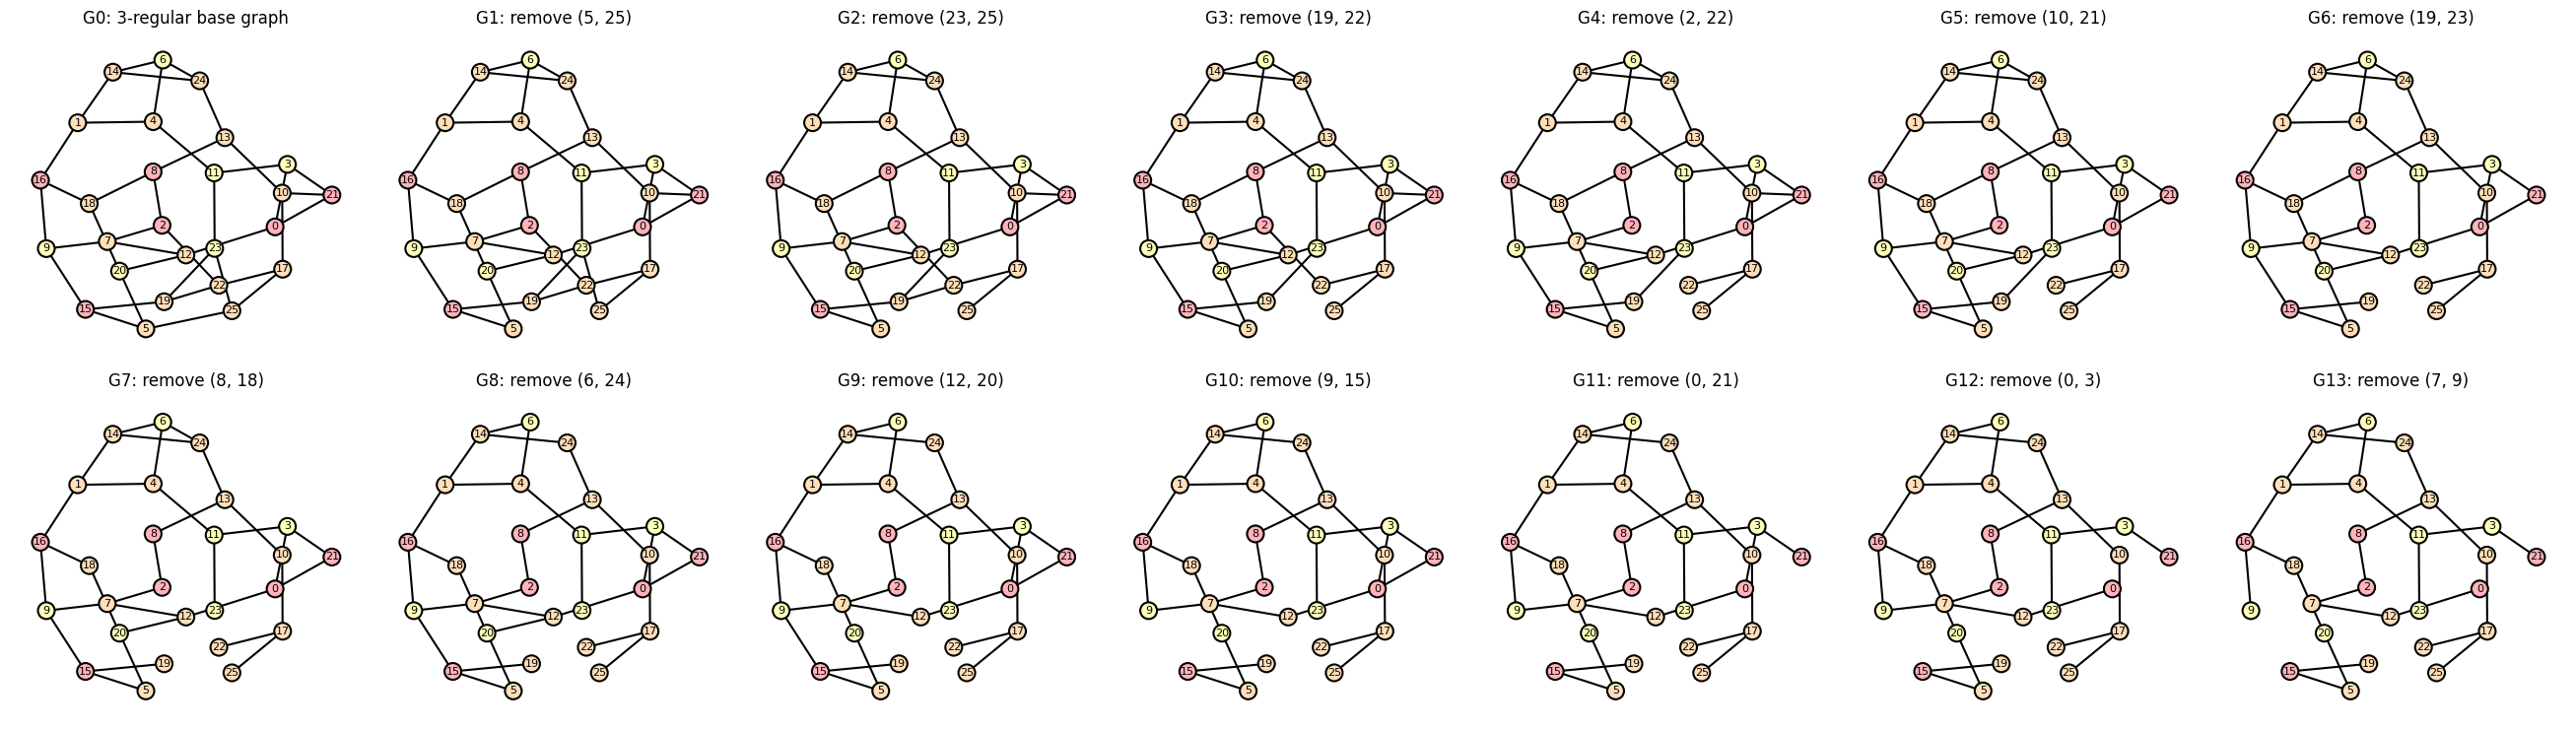

: 

In [ ]:
def generate_edge_removal_sequence(graph, n_steps=4, seed=0):
    """Create a connected graph sequence by removing one non-bridge edge at each step."""
    rng = random.Random(seed)
    graphs = [graph.copy()]
    removed_edges = []
    current_graph = graph.copy()

    for _ in range(n_steps):
        removable_edges = sorted(set(current_graph.edges()) - set(nx.bridges(current_graph)))
        if not removable_edges:
            break
        edge_to_remove = rng.choice(removable_edges)
        current_graph = current_graph.copy()
        current_graph.remove_edge(*edge_to_remove)
        graphs.append(current_graph)
        removed_edges.append(edge_to_remove)

    return graphs, removed_edges


base_graph = create_random_regular_graph(
    num_nodes=26,
    degree=3,
    alphabet_size=3,
    n_dim_vector_attribute=3,
    seed=7,
)

initial_pos = nx.kamada_kawai_layout(base_graph)
nx.set_node_attributes(base_graph, initial_pos, 'pos')

graphs, removed_edges = generate_edge_removal_sequence(base_graph, n_steps=7*2-1, seed=3)
graph_labels = [f'G{i}' for i in range(len(graphs))]
plot_titles = []
for i, label in enumerate(graph_labels):
    if i == 0:
        plot_titles.append(f'{label}: 3-regular base graph')
    else:
        plot_titles.append(f'{label}: remove {removed_edges[i - 1]}')

from utils import plot_graphs
plot_graphs(graphs, titles=plot_titles, num_graphs_per_row=7, use_pos=True)


### Inspect the exact removals

The next two small cells expose the exact edge-removal sequence and the resulting edge counts. This makes it easier to connect the later kernel behavior back to the underlying structural edits.


In [4]:
removed_edges


[(5, 25),
 (23, 25),
 (19, 22),
 (2, 22),
 (10, 21),
 (19, 23),
 (8, 18),
 (6, 24),
 (12, 20),
 (9, 15),
 (0, 21),
 (0, 3),
 (7, 9),
 (4, 6)]

In [5]:
[(label, graph.number_of_edges()) for label, graph in zip(graph_labels, graphs)]


[('G0', 39),
 ('G1', 38),
 ('G2', 37),
 ('G3', 36),
 ('G4', 35),
 ('G5', 34),
 ('G6', 33),
 ('G7', 32),
 ('G8', 31),
 ('G9', 30),
 ('G10', 29),
 ('G11', 28),
 ('G12', 27),
 ('G13', 26),
 ('G14', 25)]

We vectorize the whole sequence and inspect the graph-kernel matrix. Nearby graphs should stay more similar than graphs that are several edge removals apart.


### Graph-level NSPPK features

This cell applies `NSPPK` to the whole graph sequence, producing one feature vector per graph. The resulting cosine kernel matrix shows how graph similarity evolves as more edges are removed.


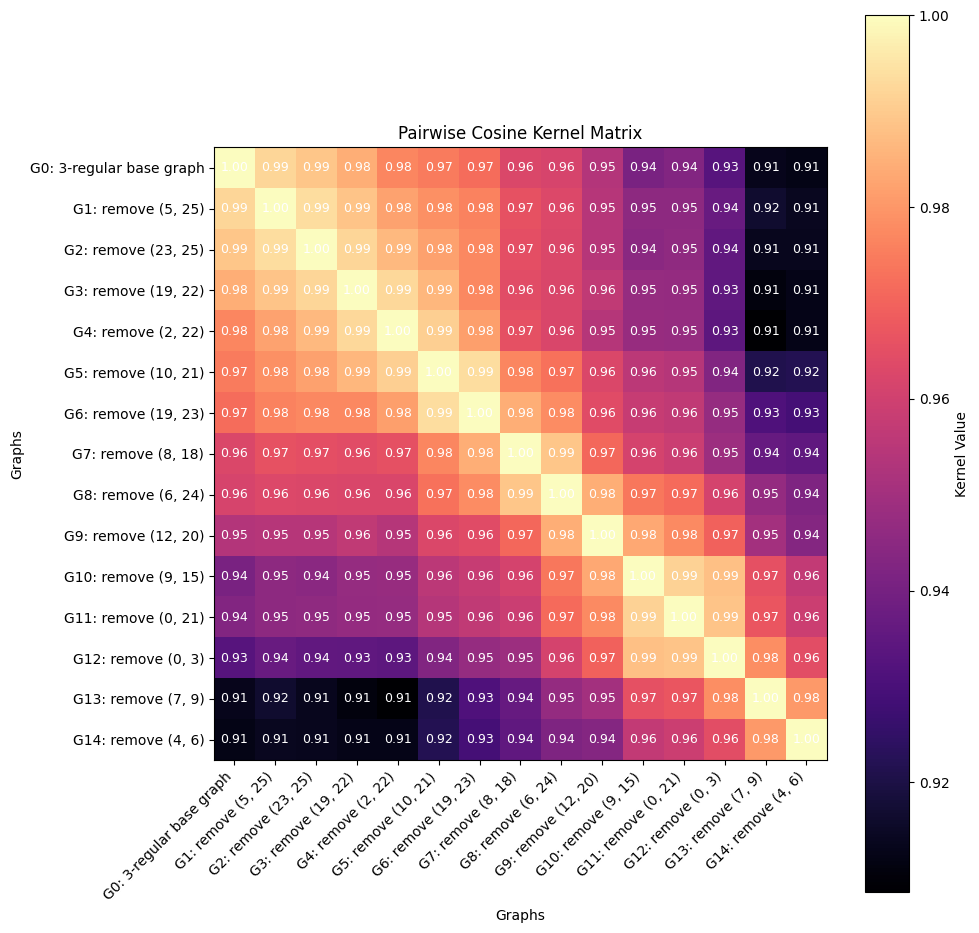

array([[1.        , 0.99218821, 0.98900281, 0.9845642 , 0.97680762,
        0.97469176, 0.97180877, 0.96276633, 0.96149596, 0.95380016,
        0.94095051, 0.94294804, 0.93308762, 0.91317389, 0.91235489],
       [0.99218821, 1.        , 0.99390455, 0.98862055, 0.98237766,
        0.97869645, 0.97615942, 0.96579234, 0.96314349, 0.9543575 ,
        0.94540946, 0.94541375, 0.93682776, 0.91661351, 0.91420993],
       [0.98900281, 0.99390455, 1.        , 0.99217642, 0.98672534,
        0.98187005, 0.97746077, 0.96500785, 0.96248112, 0.95455892,
        0.94482362, 0.94569816, 0.93564244, 0.91359866, 0.913562  ],
       [0.9845642 , 0.98862055, 0.99217642, 1.        , 0.9926457 ,
        0.98637351, 0.9772768 , 0.96440113, 0.96215245, 0.95656711,
        0.94734343, 0.94689778, 0.9349809 , 0.91070749, 0.91246059],
       [0.97680762, 0.98237766, 0.98672534, 0.9926457 , 1.        ,
        0.99071728, 0.98148037, 0.96547214, 0.96244504, 0.95416324,
        0.94779373, 0.94725398, 0.93454917, 

In [6]:
from nsppk import NSPPK

graph_vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=10, dense=True)
X = graph_vectorizer.fit_transform(graphs)
K = plot_similarity_kernel(X, labels=plot_titles, kernel='cosine')
K


We can also compare several `(radius, distance, connector)` settings across multiple random 3-regular starting graphs. For each triplet, we compute the cosine Gram matrix for every generated edge-removal sequence, extract the median row values, and plot the mean profile with a `fill_between` band of one standard deviation.


### Compare hyperparameter settings across repeated graph families

Rather than looking at just one graph sequence, this section repeats the experiment across several random initial graphs. It compares multiple `(radius, distance, connector)` choices and summarizes how quickly similarity decays under each setting.

Some random base graphs cannot support the full requested number of non-bridge edge removals. The benchmark therefore computes the longest common sequence length available across the sampled seeds, truncates all accepted sequences to that shared prefix, and compares hyperparameters on that common portion only.


Accepted seeds (10): [7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Common sequence length used for comparison: 10


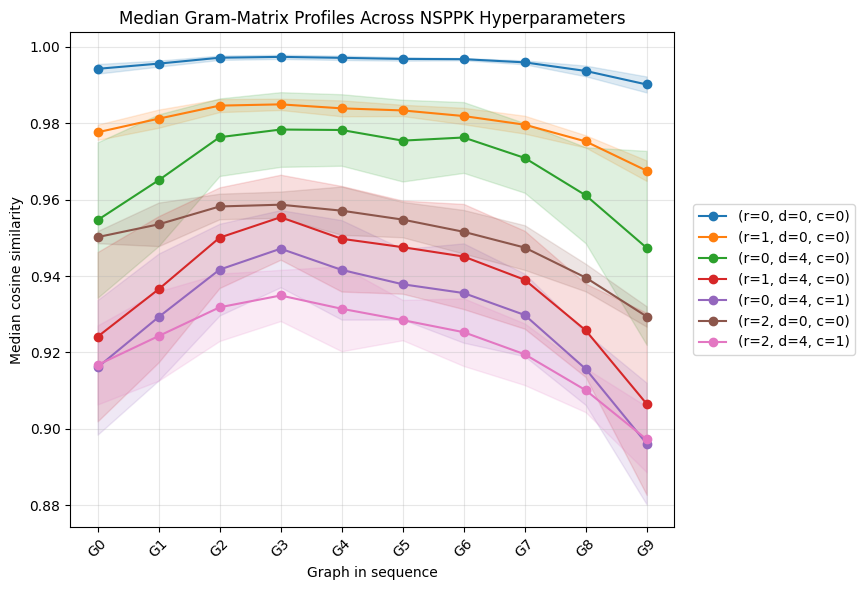

In [7]:
hyperparameter_triplets = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 4, 0),
    (1, 4, 0),
    (0, 4, 1),
    (2, 0, 0),
    (2, 4, 1),
]
num_repetitions = 10
initial_graph_seed_start = 7
initial_graph_seeds = list(range(initial_graph_seed_start, initial_graph_seed_start + num_repetitions))
requested_num_graphs = len(graphs)

generated_sequences = []
for base_seed in initial_graph_seeds:
    base_graph_rep = create_random_regular_graph(
        num_nodes=16,
        degree=3,
        alphabet_size=3,
        n_dim_vector_attribute=3,
        seed=base_seed,
    )
    graphs_rep, _ = generate_edge_removal_sequence(
        base_graph_rep,
        n_steps=requested_num_graphs - 1,
        seed=3,
    )
    generated_sequences.append((base_seed, graphs_rep))

usable_sequences = [(base_seed, graphs_rep) for base_seed, graphs_rep in generated_sequences if len(graphs_rep) >= 2]
if not usable_sequences:
    raise ValueError('No seed produced a usable connected sequence.')

common_num_graphs = min(len(graphs_rep) for _, graphs_rep in usable_sequences)
common_graph_labels = graph_labels[:common_num_graphs]
profiles_by_triplet = {triplet: [] for triplet in hyperparameter_triplets}
accepted_seeds = []
truncated_seeds = []

for base_seed, graphs_rep in usable_sequences:
    if len(graphs_rep) > common_num_graphs:
        truncated_seeds.append((base_seed, len(graphs_rep), common_num_graphs))
    graphs_rep = graphs_rep[:common_num_graphs]
    accepted_seeds.append(base_seed)

    for triplet in hyperparameter_triplets:
        radius, distance, connector = triplet
        X_triplet = NSPPK(
            radius=radius,
            distance=distance,
            connector=connector,
            nbits=10,
            dense=True,
        ).fit_transform(graphs_rep)
        K_triplet = pairwise_kernels(X_triplet, metric='cosine')
        profiles_by_triplet[triplet].append(np.median(K_triplet, axis=0))

print(f'Accepted seeds ({len(accepted_seeds)}): {accepted_seeds}')
print(f'Common sequence length used for comparison: {common_num_graphs}')
if truncated_seeds:
    print('Truncated seeds:', truncated_seeds)

plt.figure(figsize=(11, 6))
for radius, distance, connector in hyperparameter_triplets:
    triplet = (radius, distance, connector)
    profiles = np.vstack(profiles_by_triplet[triplet])
    mean_profile = profiles.mean(axis=0)
    std_profile = profiles.std(axis=0)
    x = np.arange(common_num_graphs)
    line, = plt.plot(
        x,
        mean_profile,
        marker='o',
        label=f'(r={radius}, d={distance}, c={connector})',
    )
    plt.fill_between(
        x,
        mean_profile - std_profile,
        mean_profile + std_profile,
        color=line.get_color(),
        alpha=0.15,
    )

plt.xticks(range(common_num_graphs), common_graph_labels, rotation=45)
plt.xlabel('Graph in sequence')
plt.ylabel('Median cosine similarity')
plt.title('Median Gram-Matrix Profiles Across NSPPK Hyperparameters')
plt.grid(True, alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=(0, 0, 0.8, 1))
plt.show()


We can also node-vectorize the same sequence. Each matrix has shape `(n_nodes, 2^{nbits})`. The first two aggregated node features are easy to interpret: feature `0` sums to the number of nodes, and feature `1` sums to twice the number of edges.


## Node-level NSPPK features

The graph-level kernel above aggregates all node information into one vector per graph. The next section instead uses `NodeNSPPK`, which returns one feature matrix per graph with one row per node.


In [8]:
from nsppk import NodeNSPPK

node_graph_vectorizer = NodeNSPPK(radius=1, distance=4, connector=1, nbits=10, dense=True)
mtx_list = node_graph_vectorizer.fit_transform(graphs)
mtx_list[0].shape


(26, 1024)

For this sequence, the first two aggregated node features track simple graph statistics:

1. feature `0` sums to the number of nodes
2. feature `1` sums to twice the number of edges


### Verify the interpretation of the first aggregated node features

This final table checks that the first two summed node features behave exactly as expected on the graph sequence: one recovers the number of nodes and the other recovers twice the number of edges.


In [9]:
[
    {
        'graph': label,
        'nodes': graph.number_of_nodes(),
        'edges': graph.number_of_edges(),
        'sum_feature_0': float(np.asarray(mtx.sum(axis=0)).ravel()[0]),
        'sum_feature_1': float(np.asarray(mtx.sum(axis=0)).ravel()[1]),
    }
    for label, graph, mtx in zip(graph_labels, graphs, mtx_list)
]


[{'graph': 'G0',
  'nodes': 26,
  'edges': 39,
  'sum_feature_0': 26.0,
  'sum_feature_1': 78.0},
 {'graph': 'G1',
  'nodes': 26,
  'edges': 38,
  'sum_feature_0': 26.0,
  'sum_feature_1': 76.0},
 {'graph': 'G2',
  'nodes': 26,
  'edges': 37,
  'sum_feature_0': 26.0,
  'sum_feature_1': 74.0},
 {'graph': 'G3',
  'nodes': 26,
  'edges': 36,
  'sum_feature_0': 26.0,
  'sum_feature_1': 72.0},
 {'graph': 'G4',
  'nodes': 26,
  'edges': 35,
  'sum_feature_0': 26.0,
  'sum_feature_1': 70.0},
 {'graph': 'G5',
  'nodes': 26,
  'edges': 34,
  'sum_feature_0': 26.0,
  'sum_feature_1': 68.0},
 {'graph': 'G6',
  'nodes': 26,
  'edges': 33,
  'sum_feature_0': 26.0,
  'sum_feature_1': 66.0},
 {'graph': 'G7',
  'nodes': 26,
  'edges': 32,
  'sum_feature_0': 26.0,
  'sum_feature_1': 64.0},
 {'graph': 'G8',
  'nodes': 26,
  'edges': 31,
  'sum_feature_0': 26.0,
  'sum_feature_1': 62.0},
 {'graph': 'G9',
  'nodes': 26,
  'edges': 30,
  'sum_feature_0': 26.0,
  'sum_feature_1': 60.0},
 {'graph': 'G10',
  

This completes the synthetic demo: we first built a controlled sequence of related graphs, then inspected how graph-level and node-level NSPPK representations respond to those structured edits.
